# Exploração da resposta original NASA POWER

Este notebook examina o JSON Bronze exatamente como recebido da NASA POWER. Ele complementa o notebook `02_explore_nasa_power.ipynb`, que analisa a representação tabular Silver.

## Estrutura da resposta

A resposta organiza cada parâmetro como um dicionário de datas no formato `AAAAMMDD`. Primeiro são exibidos metadados, coordenadas, unidades e quantidade de observações por variável.

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

PROJECT_ROOT = Path(".") if Path("data").exists() else Path("..")
BRONZE_PATH = (
    PROJECT_ROOT
    / "data/bronze/nasa_power/daily/municipality_code=5107925"
    / "start_date=2023-09-01/end_date=2024-04-30/weather.json"
)
MANIFEST_PATH = BRONZE_PATH.with_name("weather.manifest.json")
if not BRONZE_PATH.exists():
    raise FileNotFoundError(
        f"Resposta NASA POWER não encontrada em {BRONZE_PATH}. Execute a ingestão primeiro."
    )

document = json.loads(BRONZE_PATH.read_text(encoding="utf-8"))
manifest = json.loads(MANIFEST_PATH.read_text(encoding="utf-8"))
parameters = document["properties"]["parameter"]
units = document["parameters"]
longitude, latitude = document["geometry"]["coordinates"][:2]

parameter_summary = pd.DataFrame(
    [
        {
            "parameter": name,
            "long_name": units[name].get("longname"),
            "unit": units[name].get("units"),
            "observations": len(values),
        }
        for name, values in parameters.items()
    ]
)
print(f"Coordenadas da consulta: latitude={latitude}, longitude={longitude}")
parameter_summary

Coordenadas da consulta: latitude=-12.692, longitude=-55.776


,parameter,long_name,unit,observations
0,T2M,Temperature at 2 Meters,C,243
1,T2M_MAX,Temperature at 2 Meters Maximum,C,243
2,T2M_MIN,Temperature at 2 Meters Minimum,C,243
3,RH2M,Relative Humidity at 2 Meters,%,243
4,WS2M,Wind Speed at 2 Meters,m/s,243
5,ALLSKY_SFC_SW_DWN,All Sky Surface Shortwave Downward Irradiance,MJ/m^2/day,243
6,PRECTOTCORR,Precipitation Corrected,mm/day,243


## Conversão temporária para análise

A tabela abaixo é criada somente em memória. Datas são convertidas para o tipo temporal, e o valor de preenchimento informado no cabeçalho é tratado como ausente para que não distorça estatísticas. O JSON Bronze permanece intacto.

In [2]:
weather = pd.DataFrame(parameters)
weather.index = pd.to_datetime(weather.index, format="%Y%m%d")
weather.index.name = "date"
fill_value = document.get("header", {}).get("fill_value", -999)
weather = weather.replace(fill_value, pd.NA).sort_index()

quality = pd.DataFrame(
    {
        "null_count": weather.isna().sum(),
        "minimum": weather.min(),
        "mean": weather.mean(),
        "maximum": weather.max(),
    }
)
print(f"Datas duplicadas: {int(weather.index.duplicated().sum())}")
print(f"Período: {weather.index.min().date()} a {weather.index.max().date()}")
quality

Datas duplicadas: 0
Período: 2023-09-01 a 2024-04-30


,null_count,minimum,mean,maximum
T2M,0,23.96,27.854568,34.08
T2M_MAX,0,25.55,32.988436,41.56
T2M_MIN,0,20.92,23.373539,27.62
RH2M,0,28.01,73.654856,97.54
WS2M,0,0.02,0.092428,0.31
ALLSKY_SFC_SW_DWN,0,7.58,20.353621,28.09
PRECTOTCORR,0,0.00,5.442428,64.73


## Precipitação e temperatura

Os gráficos usam os nomes e unidades originais da fonte. A chuva diária revela a distribuição dos eventos, enquanto as três temperaturas mostram a amplitude térmica ao longo da safra.

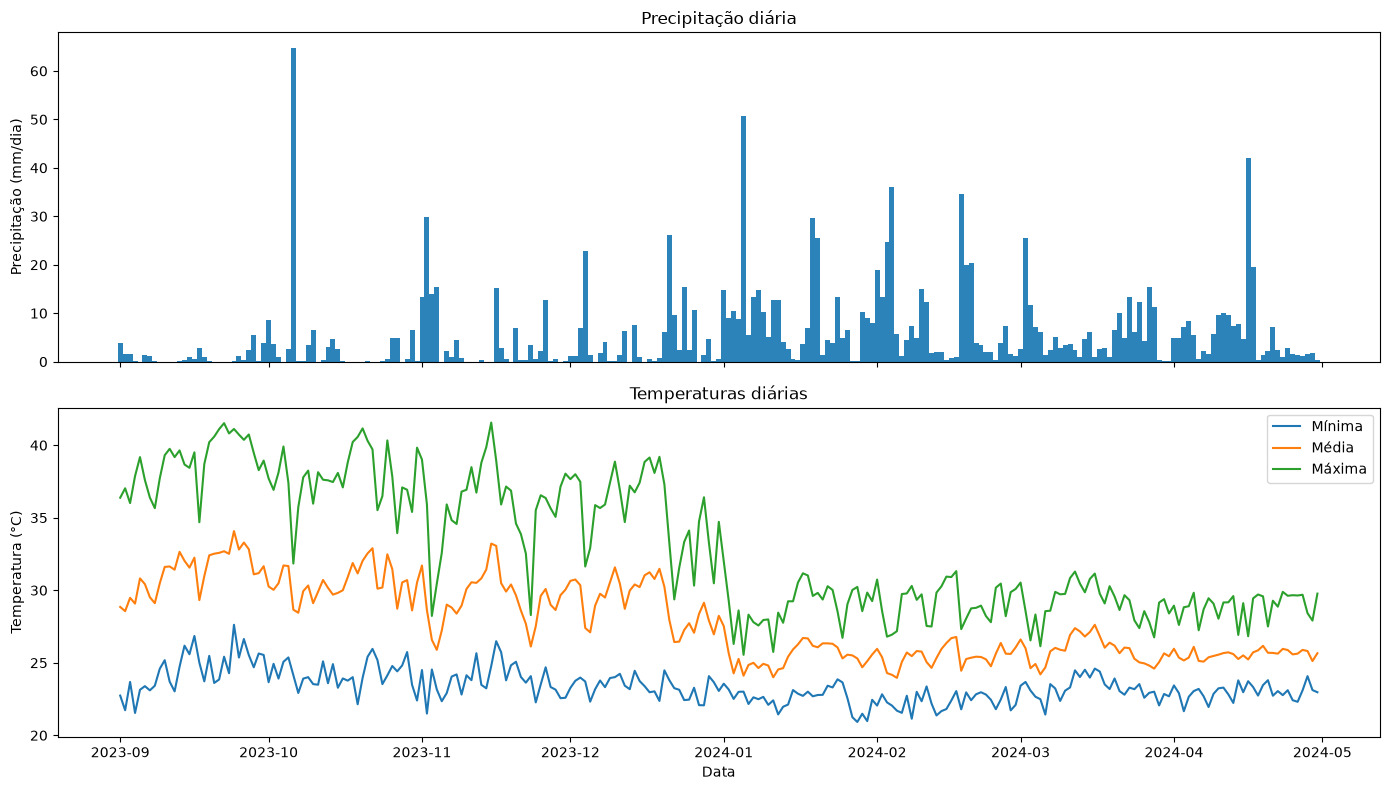

In [3]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
axes[0].bar(weather.index, weather["PRECTOTCORR"], width=1, color="#2b83ba")
axes[0].set(title="Precipitação diária", ylabel="Precipitação (mm/dia)")
axes[1].plot(weather.index, weather["T2M_MIN"], label="Mínima")
axes[1].plot(weather.index, weather["T2M"], label="Média")
axes[1].plot(weather.index, weather["T2M_MAX"], label="Máxima")
axes[1].set(title="Temperaturas diárias", xlabel="Data", ylabel="Temperatura (°C)")
axes[1].legend()
fig.tight_layout()
plt.show()

## Rastreabilidade da requisição

O manifesto registra URL, parâmetros, período, município, checksum e versão da configuração. Ele permite relacionar os valores explorados à requisição que produziu o arquivo.

In [4]:
pd.Series(manifest, name="valor").to_frame()

,valor
config_sha256,73b625776bbdaa65b2d07d8b6d4eea8304a4dc4b08edcc...
content_type,application/json
dataset,daily_point_meteorology
downloaded_at_utc,2026-08-06T02:00:35.836851+00:00
final_url,https://power.larc.nasa.gov/api/temporal/daily...
http_status,200
municipality_code,5107925
municipality_name,Sorriso
parameters,"{'community': 'AG', 'end': '20240430', 'format..."
project_version,0.1.0
